<a href="https://colab.research.google.com/github/satishiyer/Linear-Regression-Assignment/blob/main/Linear_Regression_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment Linear Regresion

Load Data

Exploratory Data Analysis

Encode Categorical Variables

Train/Test Split

Linear Regression Model

Learning Rates Iteration

Evaluation (R^2)

In [ ]:
import kagglehub
import pandas as pd

# Download dataset
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

dataset = pd.read_csv(f"{path}/Housing.csv")


# Save as Excel file
output_path = "Housing_Prices_Dataset.xlsx"
dataset.to_excel(output_path, index=False)
dataset["price_lacs"] = (dataset["price"] / 1e5).round(2)

#print("Excel file saved at:", output_path)

#from google.colab import files
#files.download("Housing_Prices_Dataset.xlsx")

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.


In [ ]:
dataset.head()
dataset.shape

(545, 14)

In [ ]:
# Quick look at data
print(dataset.head())
print(dataset.info())
print(dataset.describe())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  \
0              no             yes        2      yes        furnished   
1              no             yes        3       no        furnished   
2              no              no        2      yes   semi-furnished   
3              no             yes        3      yes        furnished   
4              no             yes        2       no        furnished   

   price_lacs  
0      133.00  
1      122.50  
2      122.50  
3      122.15  
4      114.1

In [ ]:
categorical_cols = dataset.select_dtypes(include=['object']).columns # dtype - Selecting Data Type
print("Categorical variables:", len(categorical_cols))

categorical_cols

Categorical variables: 7


Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [ ]:
integer_cols = dataset.select_dtypes(include=['int64']).columns
print("Integer variables:", len(integer_cols))

integer_cols

Integer variables: 6


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

In [ ]:
dataset.describe(include='object')

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


In [ ]:
dataset['mainroad'].unique()

array(['yes', 'no'], dtype=object)

In [ ]:
dataset['furnishingstatus'].unique()

array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)

In [ ]:
import numpy as np

# used one hot Encoding
# Convert categorical to dummy variables
dataset = pd.get_dummies(dataset, drop_first=True)
dataset


,price,area,bedrooms,bathrooms,stories,parking,price_lacs,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,133.00,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,122.50,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,122.50,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,122.15,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,114.10,True,True,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,18.20,True,False,True,False,False,False,False,True
541,1767150,2400,3,1,1,0,17.67,False,False,False,False,False,False,True,False
542,1750000,3620,2,1,1,0,17.50,True,False,False,False,False,False,False,True
543,1750000,2910,3,1,1,0,17.50,False,False,False,False,False,False,False,False


In [ ]:
# Separate features and target X is indephdent variables y is target variable
X = dataset.drop(["price", "price_lacs"], axis=1)
y = dataset["price"].values.reshape(-1, 1) #Before reshape: [13300000, 12250000, 12250000],
 #[[13300000]
 #[12250000]
 #[12250000]]
X = X.astype(np.float64)


In [ ]:
y = y / 1e5

In [ ]:
X = X.astype(np.float64) # convert X to Numpy
y = y.reshape(-1,1)

In [ ]:
# Ensure numpy (safe for both DataFrame and ndarray) machine should not learn pattern so we do indices
X = np.asarray(X)
y = np.asarray(y)

indices = np.random.permutation(X.shape[0])

X = X[indices]
y = y[indices]



In [ ]:
# Train-Test Split this will work because data is not split into ascending or descending
split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]


#from sklearn.model_selection import train_test_split you can use this also if train and test data split

#X_train, X_test, y_train, y_test = train_test_split(
   # X, y, test_size=0.2, random_state=42
#)

In [ ]:
#SCALE USING TRAIN ONLY mean & std for training data
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
std[std == 0] = 1

# apply same to test
X_train = (X_train - mean) / std # standardization
X_test = (X_test - mean) / std

# Add bias term AFTER scaling this is core intercept) 0(intercept) y=θ0​+θ1​x1​+θ2​x2​ # Price = θ0 + θ1*(area) + θ2*(bedrooms) Intercept 0 base value
X_train = np.hstack((np.ones((X_train.shape[0],1)), X_train))
X_test = np.hstack((np.ones((X_test.shape[0],1)), X_test))
print(X_train.shape)
print(X_test.shape)


(436, 14)
(109, 14)


MSE = 1
n
nX
i=1
(yi − (w · xi + b))

In [ ]:
# Cost Function
def compute_cost(X, y, theta): # theta model parameter(weights including intercept)
    m = len(y) # number of rows train X and Y
    predictions = X.dot(theta) # it calculates Y^ = X0
    errors = predictions - y # y^-y difference between predicted and actual
    cost = (1/(2*m)) * np.sum(errors**2) # average it using 1/(2m)
    return cost


In [ ]:
# Gradient Descent Function
def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []

    for i in range(iterations):
        predictions = X.dot(theta) # prediction
        errors = predictions - y   # error

        gradients = (1/m) * X.T.dot(errors) # gradient
        theta = theta - alpha * gradients   # update

        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

/tmp/ipykernel_425/103411644.py:6: RuntimeWarning: overflow encountered in square
  cost = (1/(2*m)) * np.sum(errors**2) # average it using 1/(2m)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


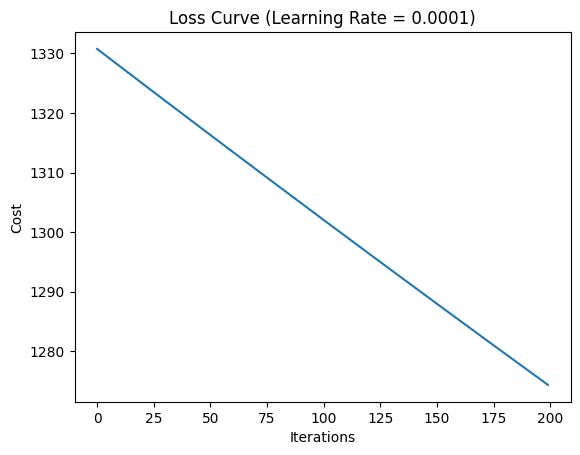

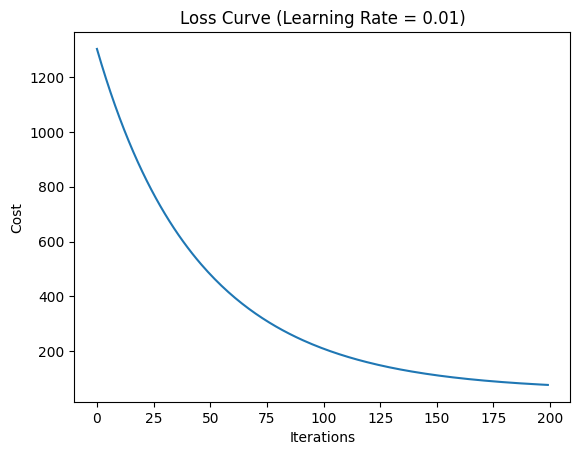

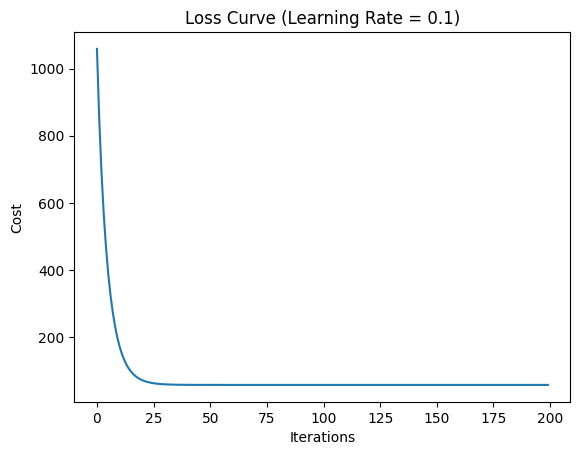

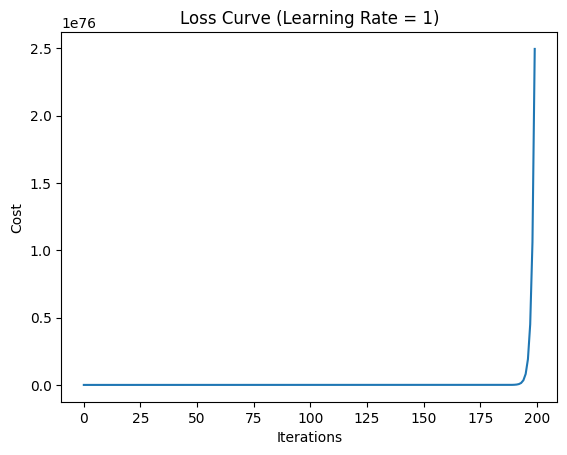

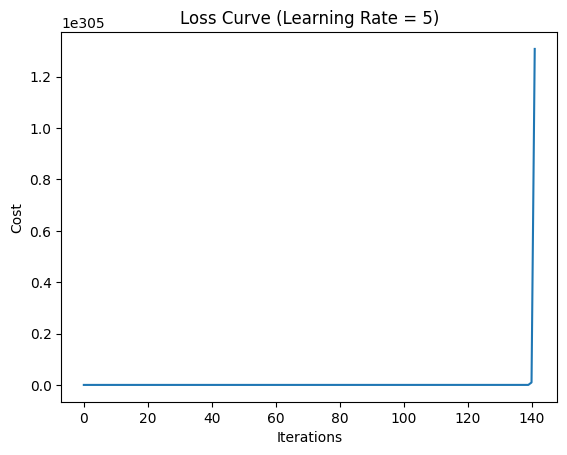

In [ ]:
learning_rates = [1e-4, 1e-2, 0.1, 1, 5]
iterations = 200

results = {}

for lr in learning_rates:
    theta_temp = np.zeros((X_train.shape[1], 1))
    theta_temp, cost_history = gradient_descent(
        X_train, y_train, theta_temp, lr, iterations
    )
    results[lr] = cost_history

import matplotlib.pyplot as plt

for lr in learning_rates:
    plt.figure()
    plt.plot(results[lr])
    plt.title(f"Loss Curve (Learning Rate = {lr})")
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.show()

In [ ]:
# Train Model - Normal Regression (No Regularization)

theta = np.zeros((X_train.shape[1], 1)) # theta contains the learned weights

alpha = 0.001
iterations = 2000

theta, cost_history = gradient_descent(
    X_train, y_train, theta, alpha, iterations
)

In [ ]:
import numpy as np
import pandas as pd

# --- 1. SET HIGH REGULARIZATION VALUES ---
# These must be high enough to "fight" the data trends
alpha = 0.01
iterations = 2000
lambda_l1 = 50.0   # High enough to force some weights to zero
lambda_l2 = 100.0  # High enough to visibly shrink all weights

# --- 2. INITIALIZE ---
theta_init = np.zeros((X_train.shape[1], 1))

# --- 3. TRAIN ALL THREE MODELS ---

# Normal Regression
theta_normal, _ = gradient_descent(
    X_train, y_train, theta_init.copy(), alpha, iterations
)

# L1 (Lasso) Regression
theta_l1, _ = gradient_descent_l1_safe(
    X_train, y_train, theta_init.copy(), alpha, iterations, lambda_l1
)

# L2 (Ridge) Regression
theta_l2, _ = gradient_descent_l2_safe(
    X_train, y_train, theta_init.copy(), alpha, iterations, lambda_l2
)

# --- 4. EVALUATION & COMPARISON ---

def get_metrics(X, y, theta):
    y_pred = X.dot(theta)
    ss_res = np.sum((y - y_pred)**2) # SSres​=∑(y−y^​)2
    ss_tot = np.sum((y - np.mean(y))**2) # SStot​=∑(y−yˉ​)2
    r2 = 1 - (ss_res / ss_tot)
    mae = np.mean(np.abs(y - y_pred))
    return r2, mae

# Calculate for all
r2_n, mae_n = get_metrics(X_test, y_test, theta_normal)
r2_l1, mae_l1 = get_metrics(X_test, y_test, theta_l1)
r2_l2, mae_l2 = get_metrics(X_test, y_test, theta_l2)

print(f"Normal  -> R2: {r2_n:.4f}, MAE: {mae_n:.2f}")
print(f"L1 Lasso -> R2: {r2_l1:.4f}, MAE: {mae_l1:.2f}")
print(f"L2 Ridge -> R2: {r2_l2:.4f}, MAE: {mae_l2:.2f}")

# --- 5. VISUALIZE WEIGHT SHRINKAGE ---
feature_names = ['Intercept'] + list(dataset.drop(["price", "price_lacs"], axis=1).columns)
# Intercept
#area
#bedrooms
#bathrooms
#stories
#mainroad
#guestroom
#basement
#airconditioning
#parking
#prefarea
#furnishingstatus

comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Normal': theta_normal.flatten(),
    'L1 (Lasso)': theta_l1.flatten(),
    'L2 (Ridge)': theta_l2.flatten()
})

print("\n--- Weight Comparison Table ---")
print(comparison_df.head(10)) # Show first 10 features

Normal  -> R2: 0.6190, MAE: 7.42
L1 Lasso -> R2: 0.6217, MAE: 7.37
L2 Ridge -> R2: 0.6227, MAE: 7.33

--- Weight Comparison Table ---
               Feature     Normal  L1 (Lasso)  L2 (Ridge)
0            Intercept  47.921000   47.921000   47.921000
1                 area   5.358665    5.336288    4.595854
2             bedrooms   1.243487    1.207675    1.588133
3            bathrooms   5.441335    5.414381    4.681011
4              stories   3.454137    3.389821    3.039173
5              parking   2.409057    2.355368    2.373107
6         mainroad_yes   1.590773    1.523308    1.631811
7        guestroom_yes   1.570999    1.519033    1.536432
8         basement_yes   1.531509    1.454034    1.324746
9  hotwaterheating_yes   1.879736    1.764256    1.502140


In [ ]:
# Create a quick dataframe to see how the weights changed
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Normal (Weights)': theta_normal.flatten(),
    'L1 Lasso (Weights)': theta_l1.flatten(),
    'L2 Ridge (Weights)': theta_l2.flatten()
})

# Add a 'Difference' column to see the shrinkage
comparison_df['L2 Shrinkage %'] = ((comparison_df['Normal (Weights)'] - comparison_df['L2 Ridge (Weights)']) / comparison_df['Normal (Weights)'] * 100).round(2)

print(comparison_df)

                            Feature  Normal (Weights)  L1 Lasso (Weights)  \
0                         Intercept         47.921000           47.921000   
1                              area          5.358665            5.336288   
2                          bedrooms          1.243487            1.207675   
3                         bathrooms          5.441335            5.414381   
4                           stories          3.454137            3.389821   
5                           parking          2.409057            2.355368   
6                      mainroad_yes          1.590773            1.523308   
7                     guestroom_yes          1.570999            1.519033   
8                      basement_yes          1.531509            1.454034   
9               hotwaterheating_yes          1.879736            1.764256   
10              airconditioning_yes          4.025269            3.960799   
11                     prefarea_yes          2.398980            2.347855   

In [ ]:
# 1. Generate predictions
y_pred_normal = X_test.dot(theta_normal)
y_pred_l1 = X_test.dot(theta_l1)
y_pred_l2 = X_test.dot(theta_l2)

# 2. Create a comparison table for the first 10 rows
comparison_table = pd.DataFrame({
    'Actual Price': y_test.flatten(),
    'Normal Pred': y_pred_normal.flatten(),
    'L1 Lasso Pred': y_pred_l1.flatten(),
    'L2 Ridge Pred': y_pred_l2.flatten()
}).head(10)

# 3. Add an "Error" column for the best performing model (L2)
comparison_table['L2 Abs Error'] = np.abs(comparison_table['Actual Price'] - comparison_table['L2 Ridge Pred'])

# Round for readability
print("--- Actual vs Predicted Prices (Lacs) ---")
print(comparison_table.round(2).to_string(index=False))

--- Actual vs Predicted Prices (Lacs) ---
 Actual Price  Normal Pred  L1 Lasso Pred  L2 Ridge Pred  L2 Abs Error
        57.40        63.10          62.99          61.99          4.59
        43.40        42.52          42.66          44.47          1.07
        39.20        47.65          47.66          47.70          8.50
        40.60        51.50          51.61          50.63         10.03
        49.00        38.26          38.30          39.56          9.44
        53.90        69.51          69.26          67.51         13.61
        59.50        56.96          56.78          56.98          2.52
       133.00        81.19          80.90          78.47         54.53
        33.32        40.73          40.77          41.94          8.62
        35.00        39.78          39.83          41.47          6.47
